# Import library

In [1]:
import requests
from requests.exceptions import HTTPError
import pprint as pp

# Make a GET Request

In [2]:
requests.get("https://api.github.com")

<Response [200]>

## Inspect the Response

It can be saved in a variable so you can now use response to see a lot of information about the results of your GET request.

In [3]:
response = requests.get("https://api.github.com")
response

<Response [200]>

### Work With Status Codes

The first piece of information that you can gather from Response is the status code. A status code informs you of the status of the request.

In [4]:
response.status_code

200

In [5]:
if response.status_code == 200:
    print("Success!")
elif response.status_code == 404:
    print("Not Found.")

Success!


In [6]:
if response:
    print("Success!")
else:
    raise Exception(f"Non-success status code: {response.status_code}")

Success!


In [7]:
import requests
from requests.exceptions import HTTPError

URLS = ["https://api.github.com", "https://api.github.com/invalid"]

for url in URLS:
    try:
        response = requests.get(url)
        response.raise_for_status()
    except HTTPError as http_err:
        print(f"HTTP error occurred: {http_err}")
    except Exception as err:
        print(f"Other error occurred: {err}")
    else:
        print("Success!")

Success!
HTTP error occurred: 404 Client Error: Not Found for url: https://api.github.com/invalid


## Access the Response Content

The response of a GET request often has some valuable information, known as a payload, in the message body. 

In [8]:
response = requests.get("https://api.github.com")
print(response.content)

print(type(response.content))

b'{\n  "current_user_url": "https://api.github.com/user",\n  "current_user_authorizations_html_url": "https://github.com/settings/connections/applications{/client_id}",\n  "authorizations_url": "https://api.github.com/authorizations",\n  "code_search_url": "https://api.github.com/search/code?q={query}{&page,per_page,sort,order}",\n  "commit_search_url": "https://api.github.com/search/commits?q={query}{&page,per_page,sort,order}",\n  "emails_url": "https://api.github.com/user/emails",\n  "emojis_url": "https://api.github.com/emojis",\n  "events_url": "https://api.github.com/events",\n  "feeds_url": "https://api.github.com/feeds",\n  "followers_url": "https://api.github.com/user/followers",\n  "following_url": "https://api.github.com/user/following{/target}",\n  "gists_url": "https://api.github.com/gists{/gist_id}",\n  "hub_url": "https://api.github.com/hub",\n  "issue_search_url": "https://api.github.com/search/issues?q={query}{&page,per_page,sort,order}",\n  "issues_url": "https://api.

In [9]:
print(response.text)

print(type(response.text))

{
  "current_user_url": "https://api.github.com/user",
  "current_user_authorizations_html_url": "https://github.com/settings/connections/applications{/client_id}",
  "authorizations_url": "https://api.github.com/authorizations",
  "code_search_url": "https://api.github.com/search/code?q={query}{&page,per_page,sort,order}",
  "commit_search_url": "https://api.github.com/search/commits?q={query}{&page,per_page,sort,order}",
  "emails_url": "https://api.github.com/user/emails",
  "emojis_url": "https://api.github.com/emojis",
  "events_url": "https://api.github.com/events",
  "feeds_url": "https://api.github.com/feeds",
  "followers_url": "https://api.github.com/user/followers",
  "following_url": "https://api.github.com/user/following{/target}",
  "gists_url": "https://api.github.com/gists{/gist_id}",
  "hub_url": "https://api.github.com/hub",
  "issue_search_url": "https://api.github.com/search/issues?q={query}{&page,per_page,sort,order}",
  "issues_url": "https://api.github.com/issues

Requests will try to guess the encoding based on the response’s headers if you don’t specify one. You can provide an explicit encoding by setting .encoding before accessing .text

In [10]:
response.encoding = "utf-8"  # Optional: Requests infers this.
print(response.text)

{
  "current_user_url": "https://api.github.com/user",
  "current_user_authorizations_html_url": "https://github.com/settings/connections/applications{/client_id}",
  "authorizations_url": "https://api.github.com/authorizations",
  "code_search_url": "https://api.github.com/search/code?q={query}{&page,per_page,sort,order}",
  "commit_search_url": "https://api.github.com/search/commits?q={query}{&page,per_page,sort,order}",
  "emails_url": "https://api.github.com/user/emails",
  "emojis_url": "https://api.github.com/emojis",
  "events_url": "https://api.github.com/events",
  "feeds_url": "https://api.github.com/feeds",
  "followers_url": "https://api.github.com/user/followers",
  "following_url": "https://api.github.com/user/following{/target}",
  "gists_url": "https://api.github.com/gists{/gist_id}",
  "hub_url": "https://api.github.com/hub",
  "issue_search_url": "https://api.github.com/search/issues?q={query}{&page,per_page,sort,order}",
  "issues_url": "https://api.github.com/issues

To get a dictionary, you could take the str that you retrieved from .text and deserialize it using json.loads(). However, the direct way to accomplish this task is to use .json()

In [11]:
print(response.json())
print(type(response.json()))

{'current_user_url': 'https://api.github.com/user', 'current_user_authorizations_html_url': 'https://github.com/settings/connections/applications{/client_id}', 'authorizations_url': 'https://api.github.com/authorizations', 'code_search_url': 'https://api.github.com/search/code?q={query}{&page,per_page,sort,order}', 'commit_search_url': 'https://api.github.com/search/commits?q={query}{&page,per_page,sort,order}', 'emails_url': 'https://api.github.com/user/emails', 'emojis_url': 'https://api.github.com/emojis', 'events_url': 'https://api.github.com/events', 'feeds_url': 'https://api.github.com/feeds', 'followers_url': 'https://api.github.com/user/followers', 'following_url': 'https://api.github.com/user/following{/target}', 'gists_url': 'https://api.github.com/gists{/gist_id}', 'hub_url': 'https://api.github.com/hub', 'issue_search_url': 'https://api.github.com/search/issues?q={query}{&page,per_page,sort,order}', 'issues_url': 'https://api.github.com/issues', 'keys_url': 'https://api.git

In [12]:
response_dict = response.json()
response_dict["emojis_url"]

'https://api.github.com/emojis'

## View Response Headers

The response headers can give you useful information, such as the content type of the response payload and how long to cache the response.

Response headers are metadata sent by the server along with the response. They don’t contain the actual data (like JSON or HTML), but they describe that data and how to handle it.

🧠 Think of it like this  
- Body → the content (e.g., JSON, HTML, image)
- Headers → instructions + information about that content

In [13]:
response = requests.get("https://api.github.com")
response.headers

{'Date': 'Wed, 22 Apr 2026 10:42:55 GMT', 'Cache-Control': 'public, max-age=60, s-maxage=60', 'Vary': 'Accept,Accept-Encoding, Accept, X-Requested-With', 'ETag': '"4f825cc84e1c733059d46e76e6df9db557ae5254f9625dfe8e1b09499c449438"', 'x-github-api-version-selected': '2022-11-28', 'Access-Control-Expose-Headers': 'ETag, Link, Location, Retry-After, X-GitHub-OTP, X-RateLimit-Limit, X-RateLimit-Remaining, X-RateLimit-Used, X-RateLimit-Resource, X-RateLimit-Reset, X-OAuth-Scopes, X-Accepted-OAuth-Scopes, X-Poll-Interval, X-GitHub-Media-Type, X-GitHub-SSO, X-GitHub-Request-Id, Deprecation, Sunset', 'Access-Control-Allow-Origin': '*', 'Strict-Transport-Security': 'max-age=31536000; includeSubdomains; preload', 'X-Frame-Options': 'deny', 'X-Content-Type-Options': 'nosniff', 'X-XSS-Protection': '0', 'Referrer-Policy': 'origin-when-cross-origin, strict-origin-when-cross-origin', 'Content-Security-Policy': "default-src 'none'", 'Server': 'github.com', 'Content-Type': 'application/json; charset=utf

The .headers attribute returns a dictionary-like object, allowing you to access header values by key. 

In [14]:
response.headers["Content-Type"]

'application/json; charset=utf-8'

In [15]:
response.headers["content-type"]
# The HTTP specification defines headers as case-insensitive

'application/json; charset=utf-8'

## Add Query String Parameters

One common way to customize a GET request is to pass values through query string parameters in the URL. To do this using get(), you pass data to params.

In [16]:
# Searck popular repos

response = requests.get(
    "https://api.github.com/search/repositories",
    params={"q": "language:python", "sort": "stars", "order": "desc"},
)

json_response = response.json()
popular_repositories = json_response["items"]
for repo in popular_repositories[:3]:
    print(f"Name: {repo['name']}")
    print(f"Description: {repo['description']}")
    print(f"Stars: {repo['stargazers_count']}\n")

Name: public-apis
Description: A collective list of free APIs
Stars: 425777

Name: free-programming-books
Description: :books: Freely available programming books
Stars: 385859

Name: system-design-primer
Description: Learn how to design large-scale systems. Prep for the system design interview.  Includes Anki flashcards.
Stars: 343653



You can pass params to get() either as a dictionary, as you’ve just done, or as a list of tuples.

In [17]:
requests.get(
"https://api.github.com/search/repositories",
[("q", "language:python"), ("sort", "stars"), ("order", "desc")])

<Response [200]>

You can even pass the values as bytes:

In [18]:
requests.get(
"https://api.github.com/search/repositories",
params=b"q=language:python&sort=stars&order=desc",
)

<Response [200]>

## Customize Request Headers

To customize headers, you pass a dictionary of HTTP headers to get() using the headers parameter. 

In [19]:
import requests

response = requests.get(
    "https://api.github.com/search/repositories",
    params={"q": '"real python"'},
    headers={"Accept": "application/vnd.github.text-match+json"},
)

json_response = response.json()
first_repository = json_response["items"][0]
print(first_repository["text_matches"][0]["matches"])

[{'text': 'Real Python', 'indices': [23, 34]}]


# Use Other HTTP Methods

Aside from GET, other popular HTTP methods include POST, PUT, DELETE, HEAD, PATCH, and OPTIONS. For each of these HTTP methods, Requests provides a function with a similar signature to get().

In [20]:
print(requests.get("https://httpbin.org/get"))
print(requests.post("https://httpbin.org/post", data={"key": "value"}))
print(requests.put("https://httpbin.org/put", data={"key": "value"}))
print(requests.delete("https://httpbin.org/delete"))
print(requests.head("https://httpbin.org/get"))
print(requests.patch("https://httpbin.org/patch", data={"key": "value"}))
print(requests.options("https://httpbin.org/get"))

<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>


In the example above, you called each function to make a request to the httpbin service using the corresponding HTTP method.

All of these functions are high-level shortcuts to requests.request(), which takes the method name as its first argument.

In [21]:
requests.request("GET", "https://httpbin.org/get")

<Response [200]>

You can inspect the responses just like you did before.

In [22]:
response = requests.head("https://httpbin.org/get")
print(response.headers["Content-Type"])


response = requests.delete("https://httpbin.org/delete")
json_response = response.json()
print(json_response["args"])

application/json
{}


# Send Request Data

The data parameter takes a dictionary, a list of tuples, bytes, or a file-like object. You’ll want to adapt the data you send in the body of your request to the specific needs of the service you’re interacting with.

In [23]:
#if your request’s content type is application/x-www-form-urlencoded, then you can send the form data as a dictionary:

requests.post("https://httpbin.org/post", data={"key": "value"})

# Same data as a list of tuples
requests.post("https://httpbin.org/post", data=[("key", "value")])


<Response [200]>

If you need to send **JSON data**, then you can use the json parameter. When you pass JSON data via json, Requests will serialize your data and add the correct Content-Type header for you.

As you learned earlier, the httpbin service accepts test requests and responds with data about the requests. For example, you can use it to inspect a basic POST request:

In [24]:
response = requests.post("https://httpbin.org/post", json={"key": "value"})
json_response = response.json()
print(json_response["data"])
print(json_response["headers"]["Content-Type"])


{"key": "value"}
application/json


# Inspect the Prepared Request

When you make a request, the Requests library prepares the request before actually sending it to the destination server. Request preparation includes things like validating headers and serializing JSON content.

You can view the PreparedRequest object by accessing .request on a Response object.

In [25]:
response = requests.post("https://httpbin.org/post", json={"key":"value"})
print(response.request)
print(response.request.headers["Content-Type"])
print(response.request.url)
print(response.request.body)


<PreparedRequest [POST]>
application/json
https://httpbin.org/post
b'{"key": "value"}'


# Use Authentication

Authentication helps a service understand who you are. Typically, you provide your credentials to a server by passing data through the Authorization header or a custom header defined by the service. All the functions in Requests that you’ve seen to this point provide a parameter called auth, which allows you to pass your credentials directly.

In [26]:
response = requests.get(
"https://httpbin.org/basic-auth/user/passwd",
auth=("user", "passwd")
)

print(response.status_code)

print(response.request.headers["Authorization"])


200
Basic dXNlcjpwYXNzd2Q=


The request succeeds if the credentials that you pass in the tuple to auth are valid.

When you pass your credentials in a tuple to the auth parameter, Requests applies the credentials using HTTP’s basic access authentication scheme under the hood.

You could make the same request by passing explicit basic authentication credentials using HTTPBasicAuth.

In [27]:
from requests.auth import HTTPBasicAuth

requests.get(
"https://httpbin.org/basic-auth/user/passwd",
auth=HTTPBasicAuth("user", "passwd")
)

print(response.status_code)

print(response.request.headers["Authorization"])

200
Basic dXNlcjpwYXNzd2Q=


Although you don’t need to be explicit for basic authentication, you might want to authenticate using another method. Requests provides other methods of authentication out of the box, such as HTTPDigestAuth and HTTPProxyAuth.

In [28]:
# No credentials
requests.get("https://api.github.com/user")

<Response [401]>

To make a request to GitHub’s authenticated user API, you first need to generate a personal access token with the read:user scope. Then, you can pass this token as the second element in a tuple to get()

In [29]:
from dotenv import load_dotenv
import os

load_dotenv()

token = os.getenv("GITHUB_TOKEN")
response = requests.get(
"https://api.github.com/user",
auth=("", token)
)
response.status_code


200

In [30]:
# response.request.headers["Authorization"]
# Result: 'Basic Omd...jA='

This method works, but it’s not the right way to authenticate with a Bearer token—and using an empty string input for the superfluous username is awkward.

With Requests, you can supply your own authentication mechanism to fix that. To try this out, create a subclass of AuthBase and implement .__call__()

In [31]:
from requests.auth import AuthBase

class TokenAuth(AuthBase):
    """Implements a token authentication scheme."""

    def __init__(self, token):
        self.token = token

    def __call__(self, request):
        """Attach an API token to the Authorization header."""
        request.headers["Authorization"] = f"Bearer {self.token}"
        return request

In [32]:
from dotenv import load_dotenv
import os

load_dotenv()

token = os.getenv("GITHUB_TOKEN")

response = requests.get(
"https://api.github.com/user",
auth=TokenAuth(token)
)

print(response.status_code)
# print(response.request.headers["Authorization"])
# The result is: 'Bearer ghp_Y...Z0'


200


# Communicate Securely With Servers

Whenever the data you’re trying to send or receive is sensitive, security becomes essential. The way that you communicate with secure sites over HTTP is by establishing an encrypted connection using Transport Layer Security (TLS). TLS is the successor to Secure Sockets Layer (SSL), offering enhanced security and efficiency in secure communications. Yet, it’s still common for programmers to use the term SSL instead of TLS.

Requests verifies the digital certificate of servers for you by default, and you rarely need to make adjustments to this behavior. However, there are some cases where you might need to customize the verification process.

requests.get(
"https://internal-api.company.com",
verify="/path/to/company-ca.pem")

>>> requests.get("https://api.github.com", verify=False)
InsecureRequestWarning: Unverified HTTPS request is being made to host
⮑ 'api.github.com'. Adding certificate verification is strongly advised.
⮑ See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
⮑  warnings.warn(
<Response [200]>

# Improve Performance

When using Requests, especially in a production application environment, it’s important to consider performance implications. Features like timeout control, sessions, and retry limits can help you keep your application running smoothly.

Note: Requests doesn’t support asynchronous HTTP requests directly. If you need async support in your program, then you should try out AIOHTTP or HTTPX. The latter library is broadly compatible with Requests’ syntax.

## Set Request Timeouts

By default, Requests will wait indefinitely on the response, so you should almost always specify a timeout duration to prevent these issues from happening. To set the request’s timeout, use the timeout parameter. timeout can be an integer or float representing the number of seconds to wait on a response before timing out:

In [33]:
requests.get("https://api.github.com", timeout=1)

<Response [200]>

>>> requests.get("https://api.github.com", timeout=0.01)
Traceback (most recent call last):
  ...
requests.exceptions.ConnectTimeout:
⮑ HTTPSConnectionPool(host='api.github.com', port=443):
⮑ Max retries exceeded with url: / (Caused by ConnectTimeoutError(...))
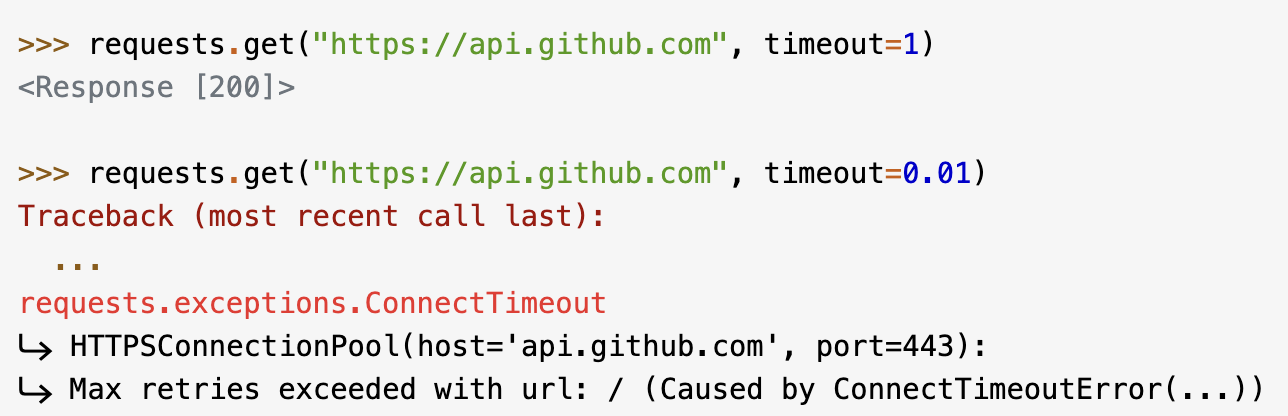

You can also pass a tuple to timeout with the following two elements:

Connect timeout: The amount of time it allows the client to establish a connection to the server
Read timeout: The time it’ll wait for a response once the client has established a connection
Both of these elements should be numbers, and can be of type int or float:

In [34]:
requests.get("https://api.github.com", timeout=(3.05, 5))

<Response [200]>

If the request establishes a connection within 3.05 seconds and receives data within 5 seconds of the connection being established, then the response will be returned as it was before. If the request times out, then the function will raise either ConnectTimeout or ReadTimeout, which are subclasses of the more general Timeout exception:

In [35]:
import requests
from requests.exceptions import Timeout

try:
    response = requests.get("https://api.github.com", timeout=(3.05, 5))
except Timeout:
    print("The request timed out")
else:
    print("The request did not time out")

The request did not time out


## Reuse Connections With Session Objects

If you need to fine-tune your control over how requests are being made or improve the performance of your requests, you may need to use a Session instance directly.

Sessions are used to persist parameters across requests. For example, if you want to use the same authentication across multiple requests, then you can use a session:

In [36]:
from dotenv import load_dotenv
import os

load_dotenv()

token = os.getenv("GITHUB_TOKEN")

with requests.Session() as session:
    session.auth = TokenAuth(token)

    first_response = session.get("https://api.github.com/user")
    second_response = session.get("https://api.github.com/user")

# pp.pprint(first_response.headers)
# pp.pprint(second_response.json())

In this example, you use a context manager to ensure that the session releases the resources when it doesn’t need them anymore.

In line 7, you attach your GitHub user’s credentials to the session object using your custom TokenAuth. You only need to do this once per session, and then you can make multiple authenticated requests. Requests will persist the credentials as long as the session lasts.

In lines 9 and 10, you then make two requests to the authenticated user API using session.get() instead of requests.get().

The primary performance optimization of sessions comes in the form of persistent connections. When your app makes a connection to a server using a Session, it keeps that connection around in a connection pool. When your app wants to connect to the same server again, it’ll reuse a connection from the pool rather than establishing a new one.

## Retry Failed Requests

When a request fails, you might want your application to retry the same request. However, Requests won’t do this for you by default. To apply this functionality, you need to implement a custom transport adapter.

Transport adapters let you define a set of configurations for each service you interact with. For example, say that you want all requests to https://api.github.com to retry twice before finally raising a RetryError. In that case, you’d build a transport adapter, set its max_retries parameter, and mount it to an existing Session

In [37]:
import requests
from requests.adapters import HTTPAdapter
from requests.exceptions import RetryError
from urllib3.util.retry import Retry

retry_strategy = Retry(
    total=2,
    status_forcelist=[429, 500, 502, 503, 504]
)
github_adapter = HTTPAdapter(max_retries=retry_strategy)

with requests.Session() as session:
    session.mount("https://api.github.com", github_adapter)
    try:
        response = session.get("https://api.github.com/")
    except RetryError as err:
        print(f"Error: {err}")

In this example, you’ve set up your session so that it’ll retry a maximum of two times if your request to GitHub’s API doesn’t work as expected. The Retry object gives you fine-grained control over which status codes should trigger retries.

The max_retries argument takes either an integer or a Retry object. Using a Retry object gives you detailed control over which failures are retried. While you can still pass a simple integer for basic cases, using a Retry object is the modern approach.

When you mount the HTTPAdapter to session, then session will adhere to its configuration for each request to https://api.github.com.

Note: While the implementation shown above works, you won’t see any effects of the retry behavior unless there’s something wrong with your network connection or GitHub’s servers.

# Website

- [Python's Requests Library (Guide)](https://realpython.com/python-requests/#getting-started-with-pythons-requests-library)
- [Drive document](https://docs.google.com/document/d/1gtFakKKySMgT9D0cRjhij1TuncKhBFhLSkiuf-4Cpi8/edit?usp=sharing)
- [GitHub API generate tokens](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-personal-access-token-classic)
- [API password / token](https://docs.google.com/document/d/1moSFZPRkBBS4lOCmiSN3GeO002lglbPpirdBePPtwmw/edit?usp=sharing)